## Assignment 1: Machine Learning Methods

### \<Zihan Luo> \<a1916700>

#### How can we use health measurements to predict obesity
The dataset provided has two forms of direct/indirect obesity measures. The first is a categorisation (NObeyesdad). 
NObesity values are:
- Underweight Less than 18.5
- Normal 18.5 to 24.9
- Overweight 25.0 to 29.9
- Obesity I 30.0 to 34.9
- Obesity II 35.0 to 39.9
- Obesity III Higher than 40

The second can be done directly via Body Mass Index (BMI) which can be derived from height and weight (use your magical Google skills to find the formula).

The goal here is to do some data modelling to achieve the following:
- What recommendations would you make to the public to reduce the rate of obesity (backed by evidence)?

#### Metric Descriptions

Other provided metrics include:
Gender, Age

The attributes related with eating habits are: 
- Frequent consumption of high caloric food (FAVC)
- Frequency of consumption of vegetables (FCVC)
- Number of main meals (NCP)
- Consumption of food between meals (CAEC)
- Consumption of water daily (CH20)
- Consumption of alcohol (CALC).

The attributes related with the physical condition are: 
- Calories consumption monitoring (SCC)
- Physical activity frequency (FAF)
- Time using technology devices (TUE)
- Transportation used (MTRANS)

### 1. Read the dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score


from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,r2_score,mean_squared_error

In [4]:
# read file
df = pd.read_csv("ObesityDataSet.csv")

# check size
df.shape

# check first 5 lines
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
# Check all columns
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [6]:
# Check for missing values
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [7]:
# check file information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [8]:
# check all numerical data distribution for outlier
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### 2. Analyse and visualise the data

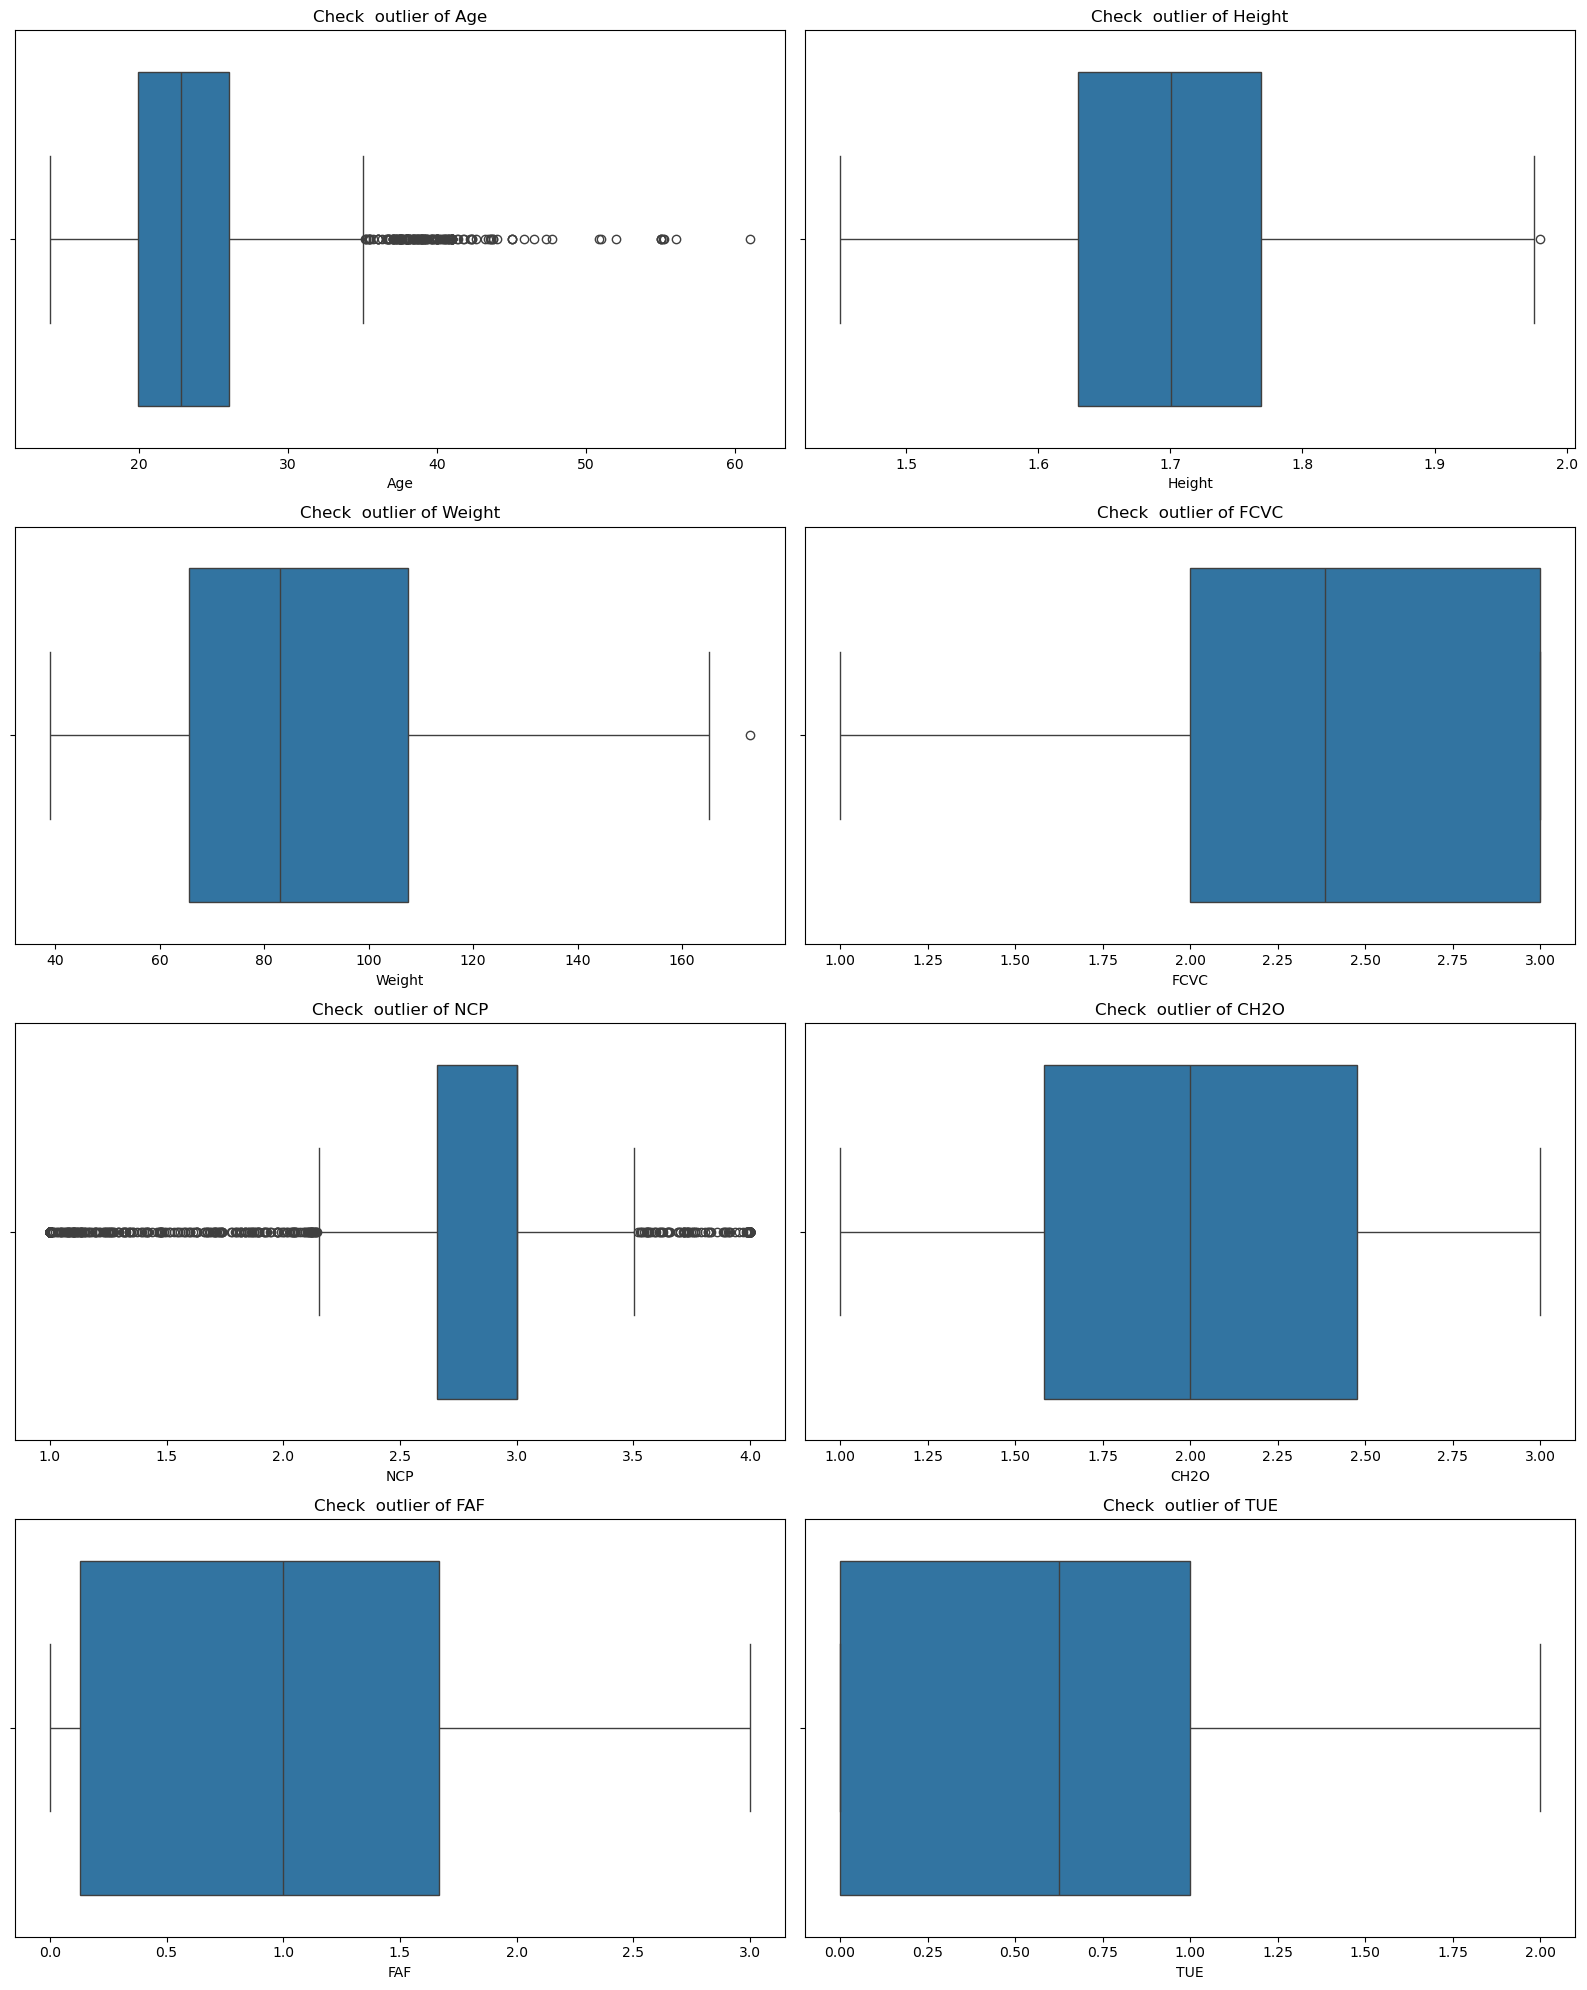

In [10]:
numerical = [ i for i  in df.columns if df[i].dtype == 'float64' ]
# print(numerical)

n_cols = 2
n_rows = (len(numerical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

# check  outlier ,especially in height and weight
for idx, col in enumerate(numerical):
    sns.boxplot(x=df[col][1:], data=df.iloc[1:], ax=axes[idx])
    axes[idx].set_title("Check  outlier of {}".format(col))

plt.tight_layout()
plt.show()

In [11]:
# delete outlier :  Weight more than  160kg 
df = df[df['Weight'] <= 160]
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2107.000000,2107.000000,2107.000000,2107.000000,2107.000000,2107.000000,2107.000000,2107.000000
mean,24.320363,1.701438,86.437369,2.417940,2.685031,2.007609,1.010073,0.657660
std,6.349113,0.093222,25.991535,0.533832,0.778656,0.613412,0.850535,0.609414
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.949372,1.630000,65.393941,2.000000,2.658558,1.575789,0.124505,0.000000
50%,22.804818,1.700181,82.967937,2.381164,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768019,107.066802,3.000000,3.000000,2.479558,1.665556,1.000000
max,61.000000,1.980000,155.872093,3.000000,4.000000,3.000000,3.000000,2.000000


In [12]:
df['NObeyesdad'].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

In [13]:
df_numeric = df.select_dtypes(include='number')
df_numeric.corr()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000000,-0.024302,0.208154,0.017650,-0.043476,-0.045051,-0.144522,-0.296731
Height,-0.024302,1.000000,0.460129,-0.041035,0.243119,0.212970,0.295143,0.051537
Weight,0.208154,0.460129,1.000000,0.211997,0.106099,0.200425,-0.052871,-0.073263
FCVC,0.017650,-0.041035,0.211997,1.000000,0.041434,0.067837,0.019694,-0.101633
NCP,-0.043476,0.243119,0.106099,0.041434,1.000000,0.056843,0.129549,0.036200
CH2O,-0.045051,0.212970,0.200425,0.067837,0.056843,1.000000,0.167933,0.012050
FAF,-0.144522,0.295143,-0.052871,0.019694,0.129549,0.167933,1.000000,0.057903
TUE,-0.296731,0.051537,-0.073263,-0.101633,0.036200,0.012050,0.057903,1.000000


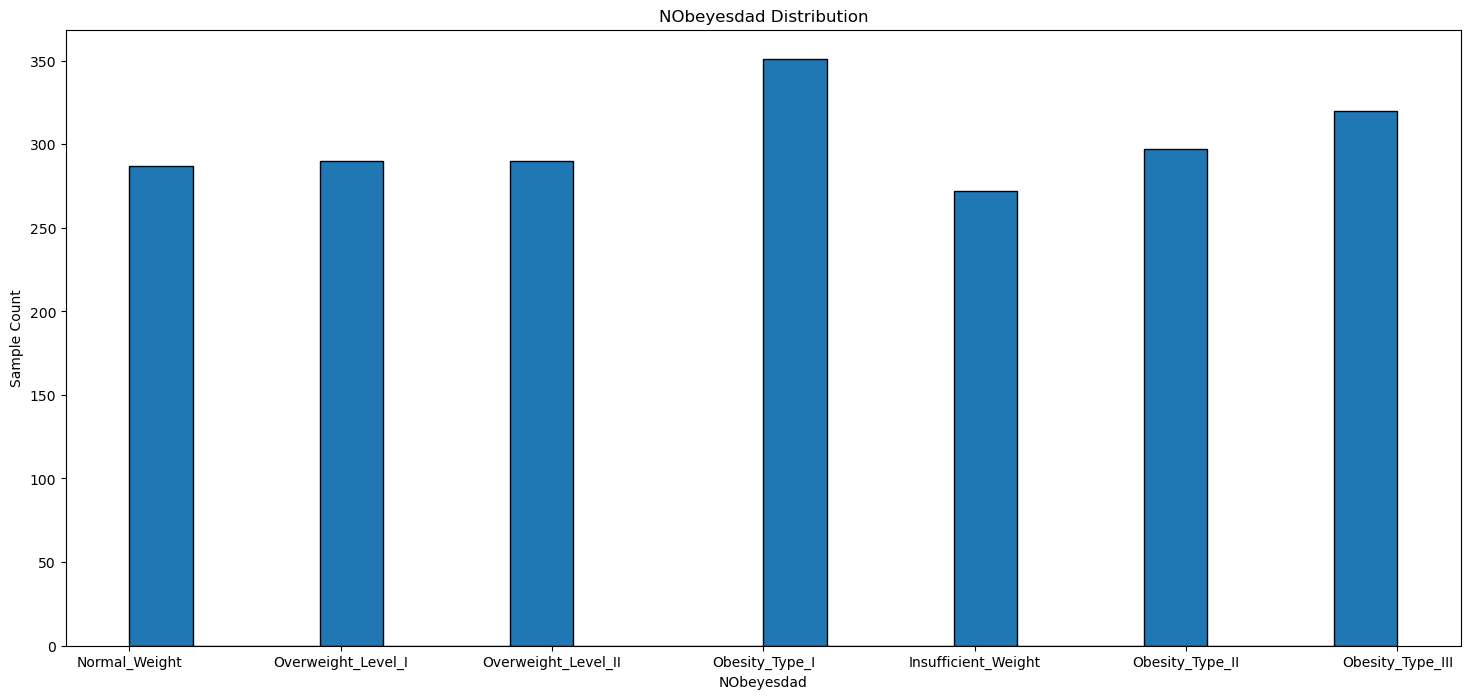

In [14]:
# show NObeyesdad distribution
plt.figure(figsize=(18, 8))
plt.hist(df['NObeyesdad'], bins=20, edgecolor='black')
plt.title('NObeyesdad Distribution')
plt.xlabel('NObeyesdad')
plt.ylabel('Sample Count')

plt.show()

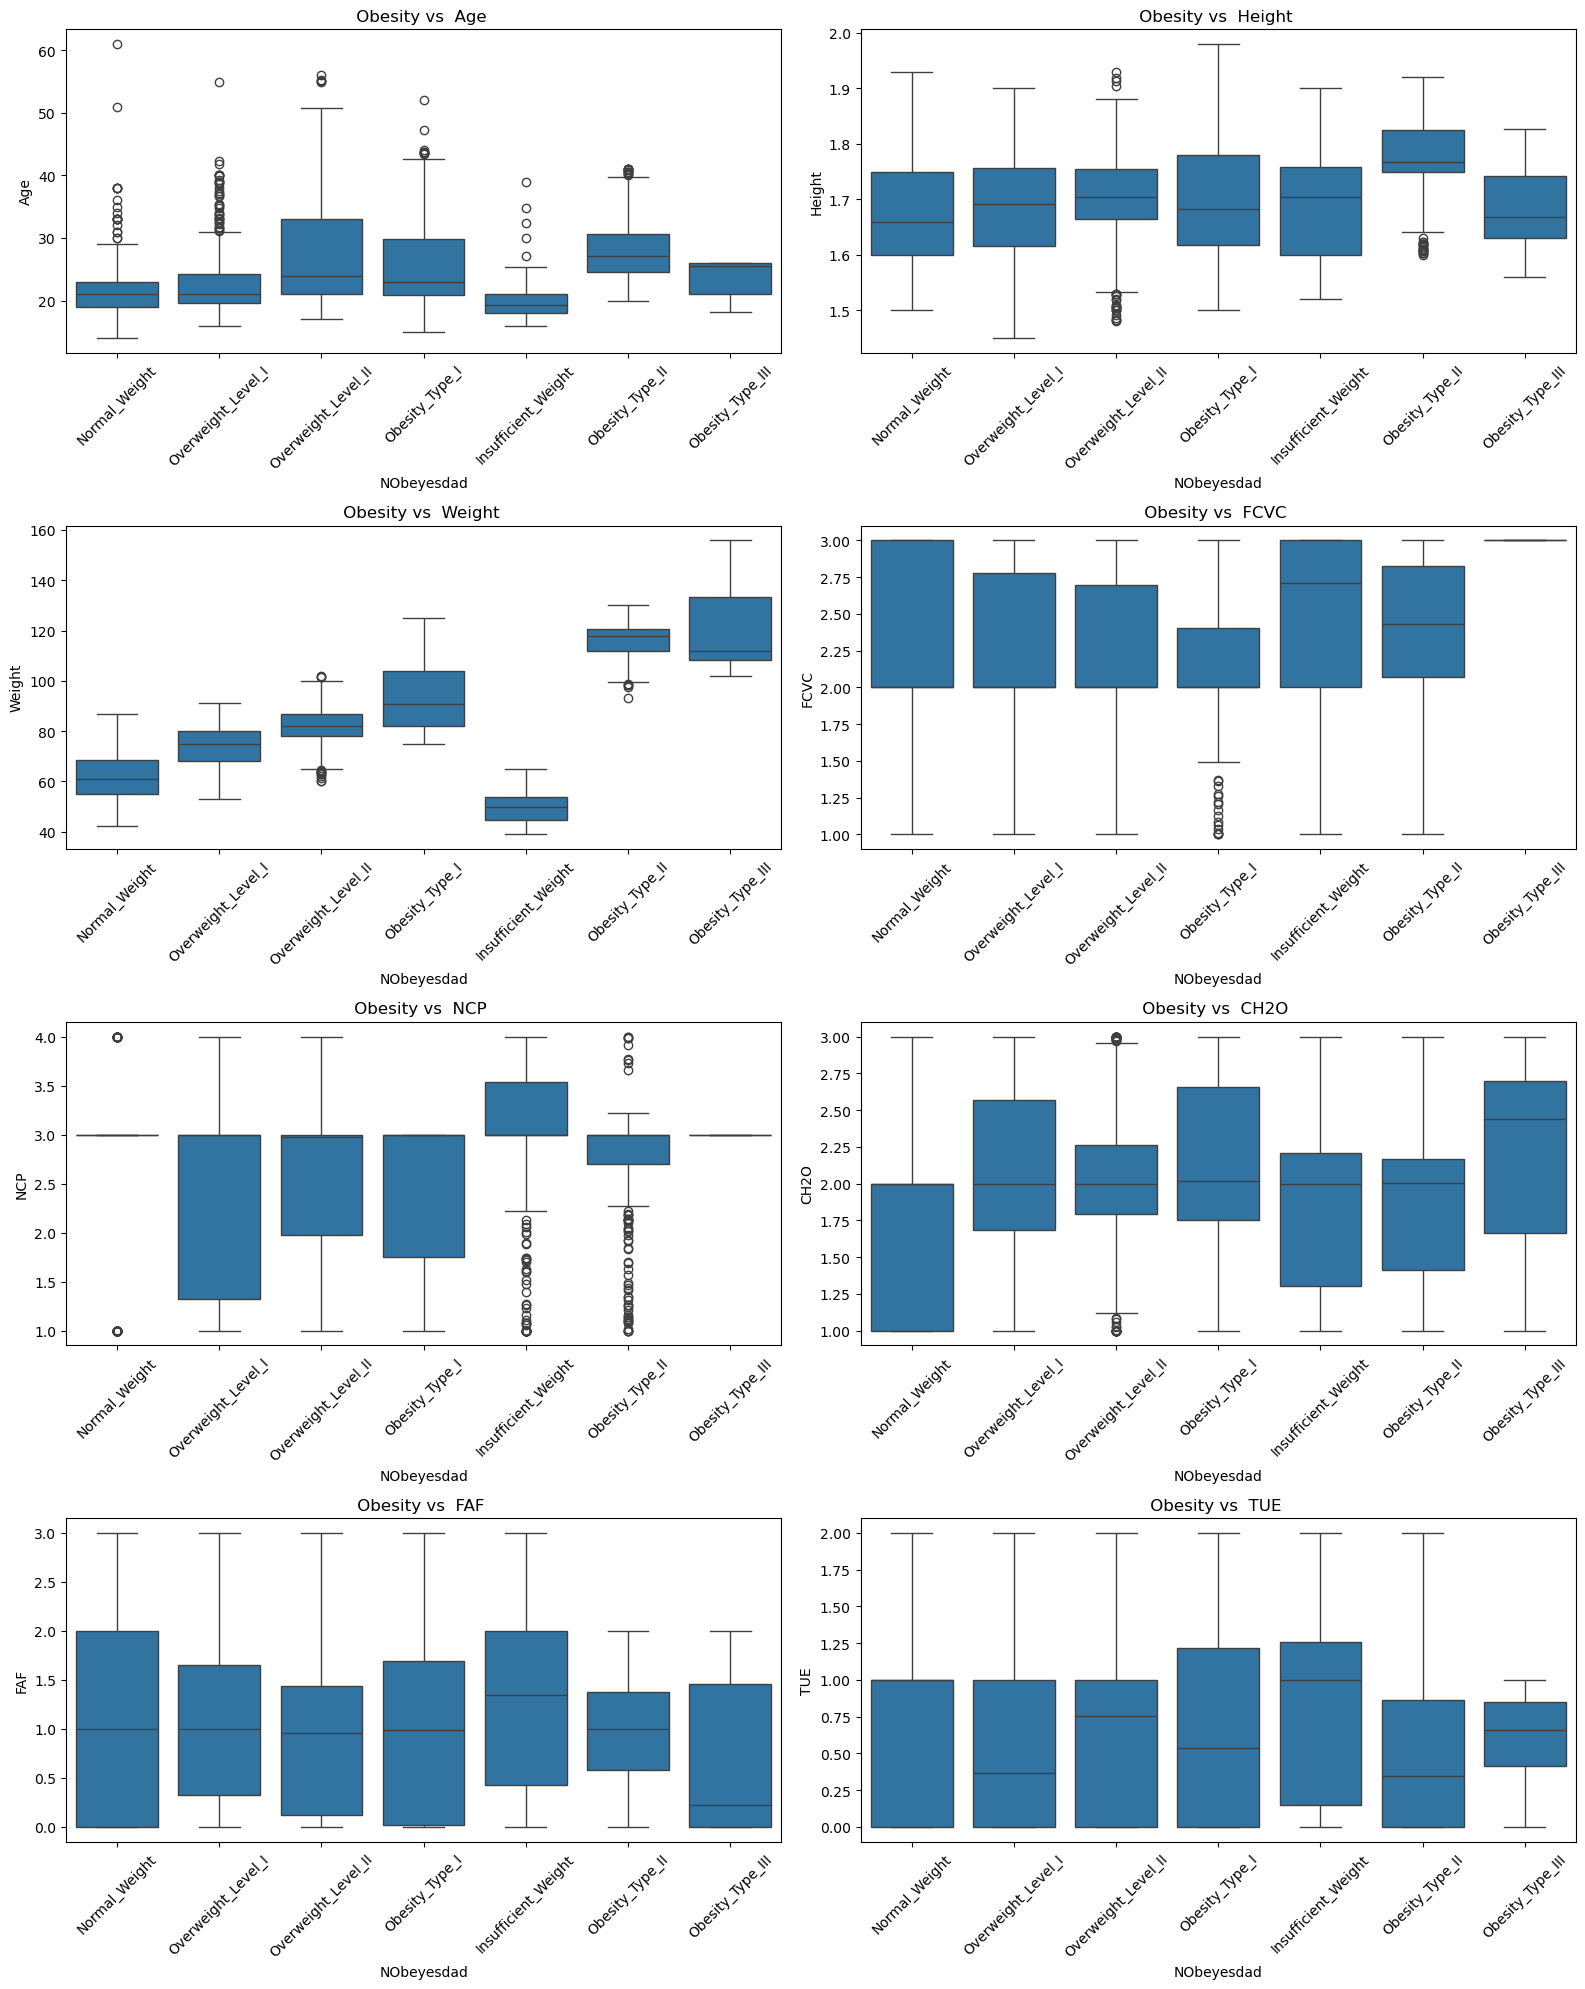

In [15]:
# choose all numerical data

numerical = [col for col in df.columns if df[col].dtype in ['float64']]

n_cols = 2
n_rows = (len(numerical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical):
    sns.boxplot(x='NObeyesdad', y=col, data=df, ax=axes[i])
    axes[i].set_title(f" Obesity vs  {col}  ")
    axes[i].tick_params(axis='x', rotation=45)



plt.tight_layout()
plt.show()



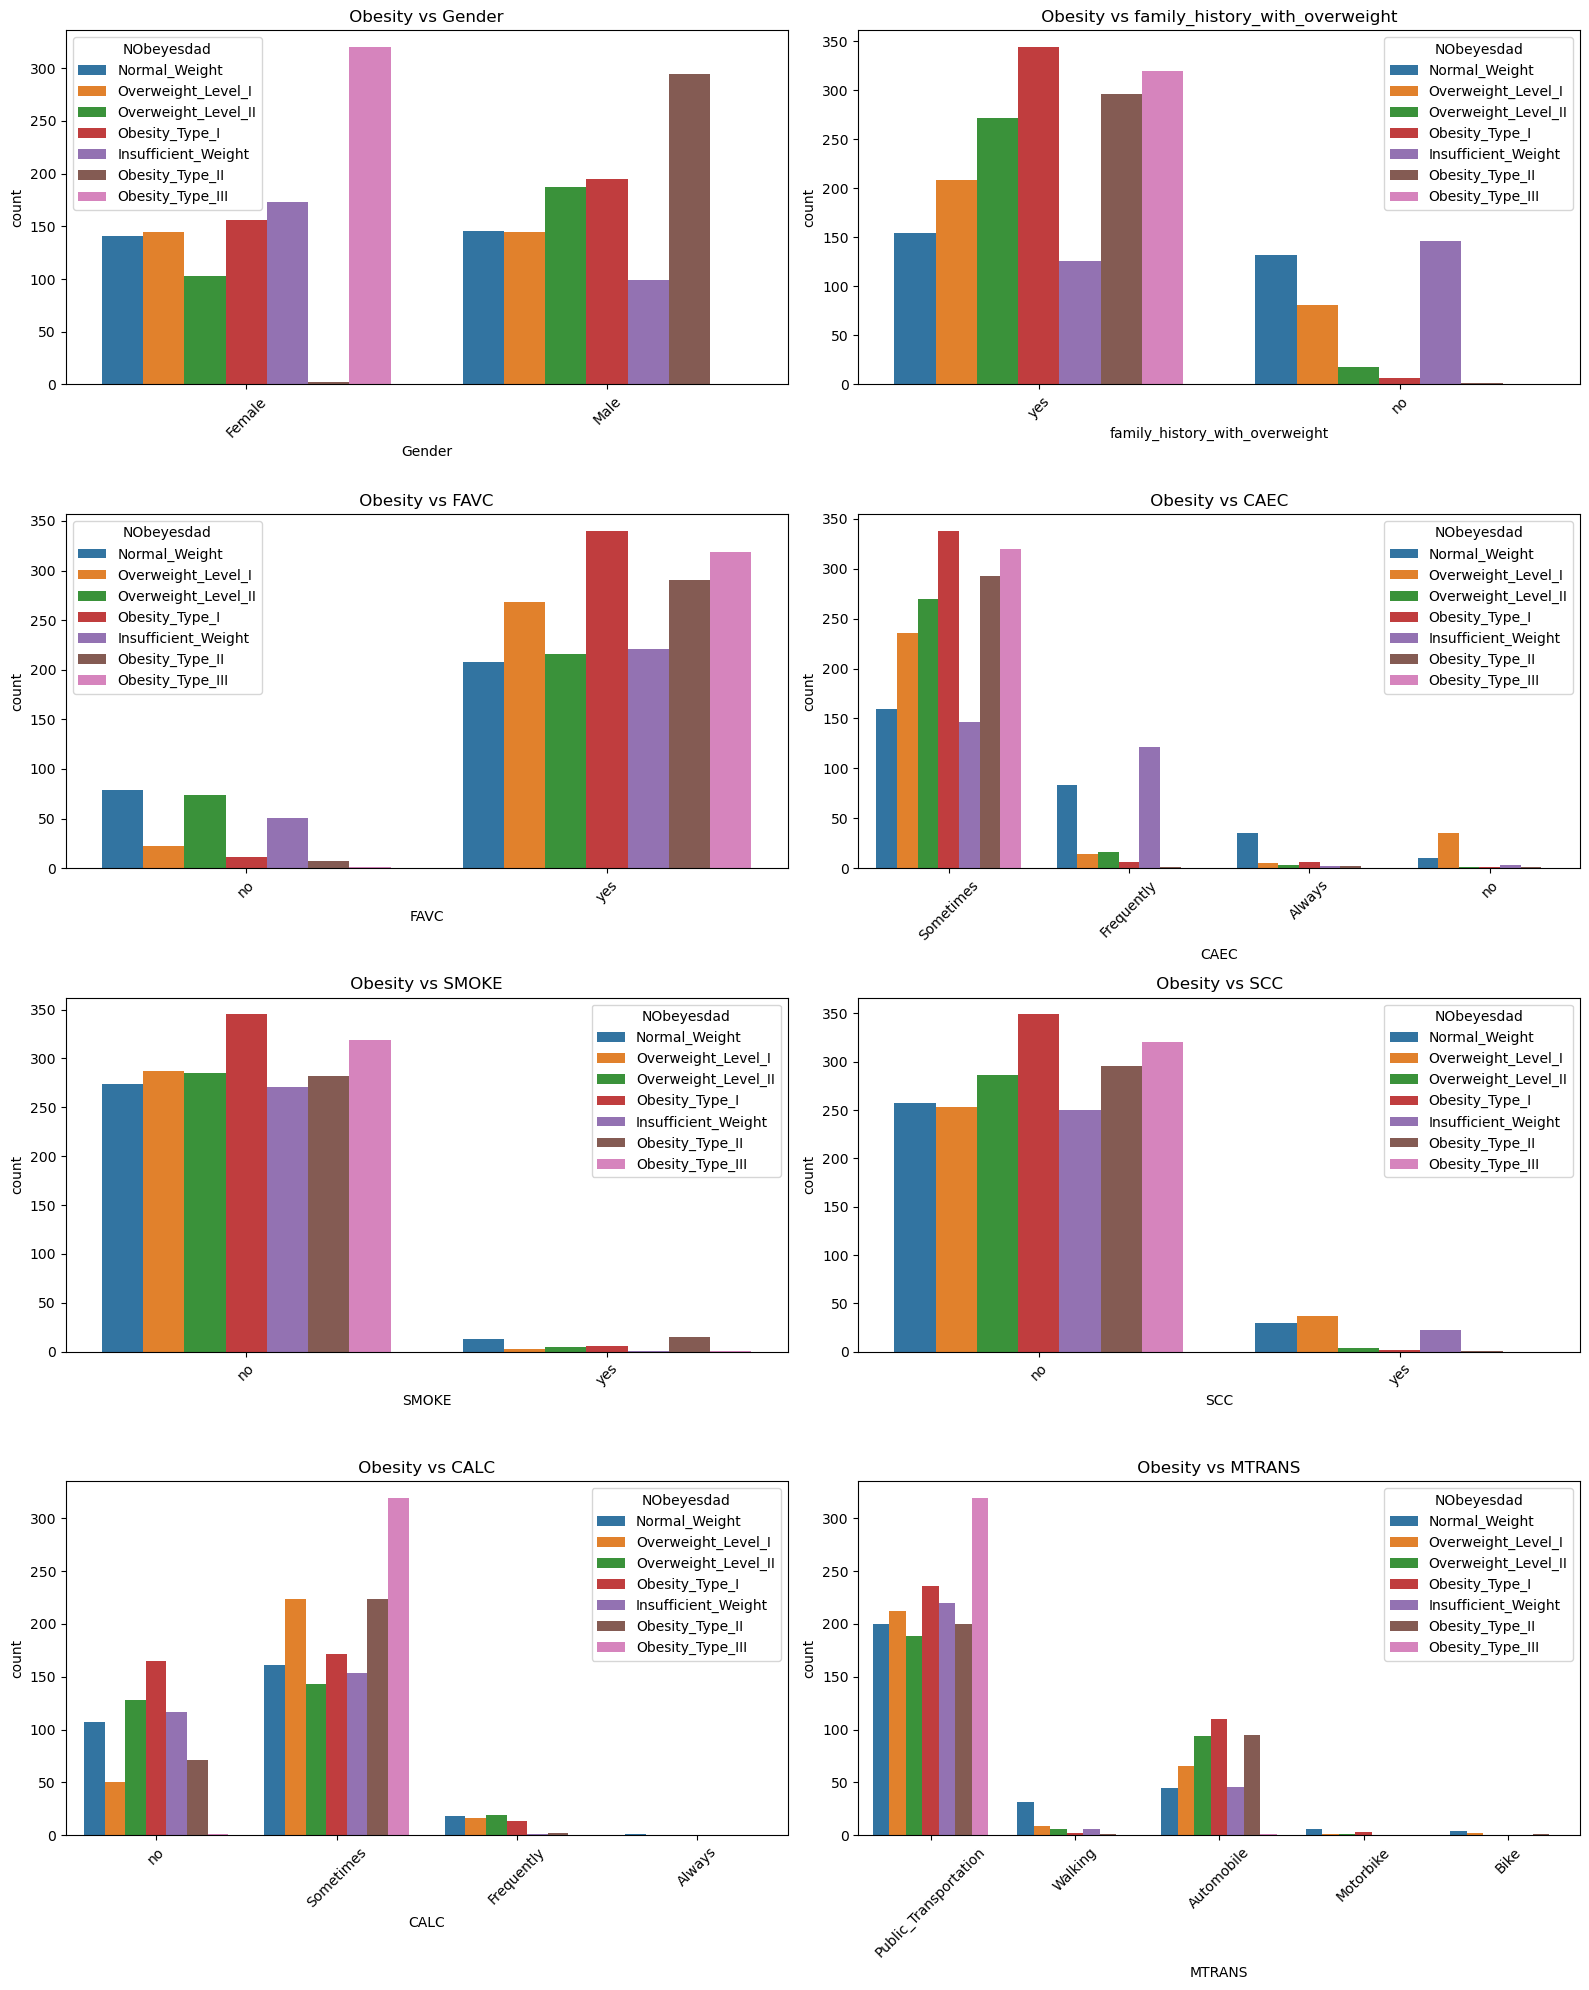

In [16]:
# choose all categorical
categorical = [col for col in df.columns if df[col].dtype == 'object'  and col != 'NObeyesdad']

n_cols = 2
n_rows = (len(categorical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical):
    sns.countplot(data=df, x=col, hue='NObeyesdad', ax=axes[i])
    axes[i].set_title(f" Obesity vs {col} ")
    axes[i].tick_params(axis='x', rotation=45)



plt.tight_layout()
plt.show()


### 3. Organise the data for modelling

In [18]:
df_encoded = df.copy()
df_encoded['BMI'] =( (df_encoded['Weight'] / (df_encoded['Height'] ** 2))).round(1)
le = LabelEncoder()

for i in df_encoded.select_dtypes(include='object').columns:
    df_encoded[i] = le.fit_transform(df_encoded[i])
    
df_encoded.head()
# df_encoded.dtypes

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1,24.4
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1,24.2
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1,23.8
3,1,27.0,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5,26.9
4,1,22.0,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6,28.3


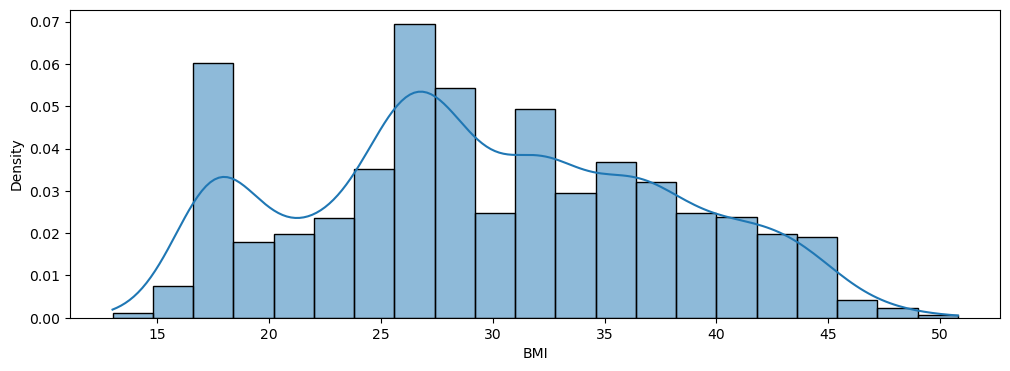

In [19]:
# show BMI distribution
plt.figure(figsize=(12, 4))
sns.histplot(df_encoded['BMI'], kde=True, stat='density')
plt.show()

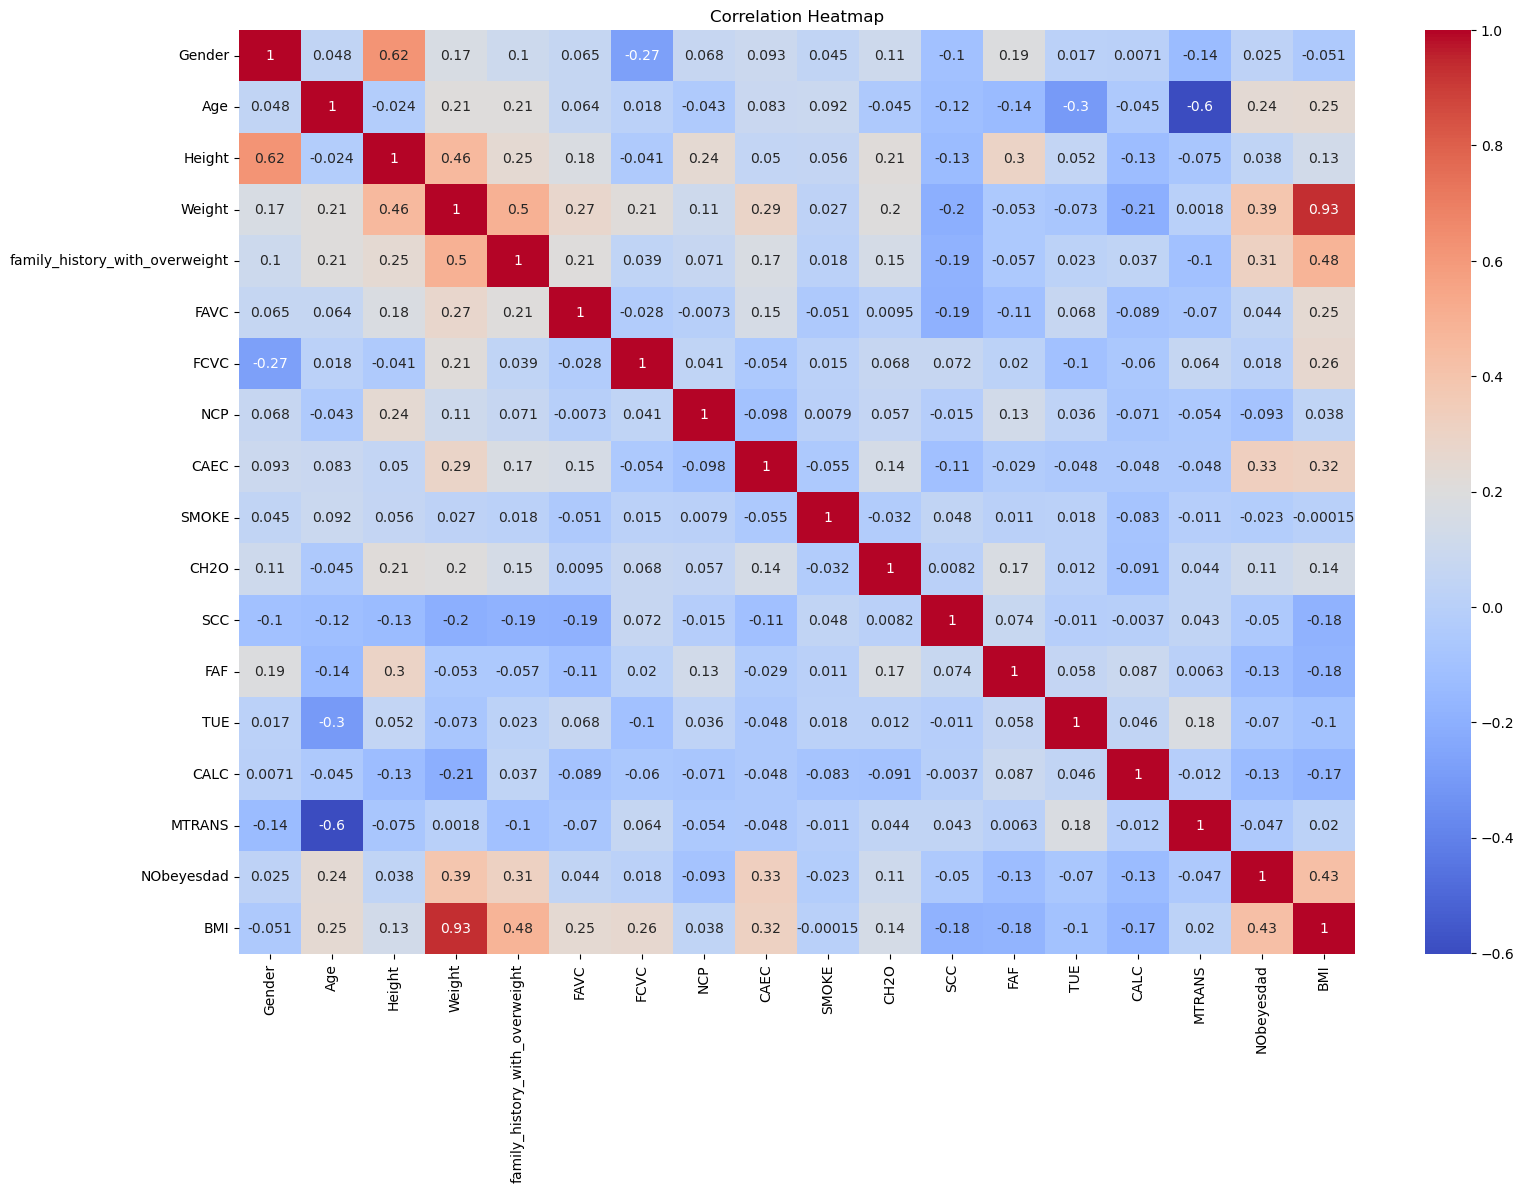

In [20]:
plt.figure(figsize=(18, 12))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 3.1 Features for classification model

In [22]:
df_encoded.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad', 'BMI'],
      dtype='object')

In [23]:
## drop(['BMI','Weight', 'Height','NObeyesdad','Gender','Age','SCC','CH2O','SMOKE','TUE']) 
class_features = [ "family_history_with_overweight","FAVC", "FCVC", "CAEC", "CALC", "NCP", "FAF","MTRANS",'Weight',]


X_class = df_encoded[class_features]
y_class = df_encoded['NObeyesdad']


scaler = StandardScaler()
X_scaled_class = scaler.fit_transform(X_class)

### 3.2 Features for regression model

In [25]:
# drop(['BMI','NObeyesdad']) , then use RFE to choose important features

X_reg = df_encoded.drop(['NObeyesdad','BMI', 'Height', 'Weight'],axis=1)
y_reg = df_encoded['BMI']


In [26]:
# train_test_split, training 80%, test 20% for class model
X_train, X_test, y_train, y_test = train_test_split(X_scaled_class, y_class, test_size=0.2, random_state=42)

In [27]:
# train_test_split, training 80%, test 20% for regression model
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

### 4. Implement prediction models

### 4.1 Random Forest (class model)

In [30]:
model_random = RandomForestClassifier(n_estimators=100, random_state=42)

### 4.2 KNN (class model)

In [32]:
model_knn = KNeighborsClassifier(n_neighbors=5)

### 4.3 LinearRegression ( regression model)

In [34]:
model_reg = LinearRegression()

### 5. Train prediction models

### 5.1 Random Forest ( class model)  predict 'NObeyesdad'

In [37]:
model_random.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 5.2 KNN ( class model)  predict 'NObeyesdad'

In [39]:
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

### 5.3 LinearRegression (regression model) predict 'BMI'

In [41]:
model_reg.fit(X_train_reg,y_train_reg)

feature_names = X_reg.columns  
rfe = RFE(model_reg, n_features_to_select=12)
rfe = rfe.fit(X_reg, y_reg)

selected_features = feature_names[rfe.support_]
print("Selected features:", selected_features)

Selected features: Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS'],
      dtype='object')


In [42]:
X_train_new = X_reg[selected_features]
X_train_new = sm.add_constant(X_train_new)
lr_model = sm.OLS(y_reg, X_train_new).fit()

### 6. Test prediction models and show results

   ### 6.1 Random Forest

In [45]:
random_predict = model_random.predict(X_test)

RF_accuracy = accuracy_score(y_test, random_predict)
RF_precision = precision_score(y_test, random_predict, average='weighted')
RF_recall = recall_score(y_test, random_predict, average='weighted')
RF_f1 = f1_score(y_test, random_predict, average='weighted')

print("Random Forest accuracy:", RF_accuracy)
print("Random Forest precision:", RF_precision)
print("Random Forest recall:", RF_recall)
print("Random Forest F1 Score:", RF_f1)

Random Forest accuracy: 0.8815165876777251
Random Forest precision: 0.8825940473851033
Random Forest recall: 0.8815165876777251
Random Forest F1 Score: 0.8813283774455596


In [46]:

cv_random_scores = cross_val_score(model_random, X_scaled_class, y_class, cv=5)

print("Cross-validation scores:", cv_random_scores)
print("Average score:", cv_random_scores.mean())
cross_random = cv_random_scores.mean()


Cross-validation scores: [0.64691943 0.93601896 0.93111639 0.93349169 0.93586698]
Average score: 0.8766826896016029


In [47]:
# save results
result_dict_train = {}
result_dict_test = {}
result_dict_train["Random Forest"] = model_random.score(X_train, y_train)
result_dict_test["Random Forest"] = model_random.score(X_test, y_test)

### 6.2 KNN

In [49]:
y_pred_knn = model_knn.predict(X_test)


KNN_accuracy = accuracy_score(y_test, y_pred_knn)
KNN_precision = precision_score(y_test, y_pred_knn, average='weighted')
KNN_recall = recall_score(y_test, y_pred_knn, average='weighted')
KNN_f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN  accuracy:", KNN_accuracy)
print("KNN precision:", KNN_precision)
print("KNN ecall:", KNN_recall)
print("KNN F1 Score:", KNN_f1)


KNN  accuracy: 0.7417061611374408
KNN precision: 0.7362353361688854
KNN ecall: 0.7417061611374408
KNN F1 Score: 0.737371545067031


In [50]:
cv_knn_scores = cross_val_score(model_knn, X_scaled_class, y_class, cv=5)

print("Cross-validation scores:", cv_random_scores)
print("Average score:", cv_knn_scores.mean())
cross_knn = cv_knn_scores.mean()

Cross-validation scores: [0.64691943 0.93601896 0.93111639 0.93349169 0.93586698]
Average score: 0.7485427384584211


In [51]:
# save results
result_dict_train["KNN"] = model_knn.score(X_train, y_train)
result_dict_test["KNN"] = model_knn.score(X_test, y_test)

### 6.3 LinearRegression

In [53]:
y_pred_reg = model_reg.predict(X_test_reg)

print("Selected features:", selected_features.tolist())
lr_model.summary()

Selected features: ['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BMI   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     131.8
Date:                Sun, 06 Apr 2025   Prob (F-statistic):          2.19e-245
Time:                        20:00:31   Log-Likelihood:                -6770.6
No. Observations:                2107   AIC:                         1.357e+04
Df Residuals:                    2094   BIC:                         1.364e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              9.4916      1.233      7.698      0.000       7.074      11.910
Gender                            -0.5387      0.287     -1.878      0.060      -1.101       0.024
family_history_with_overweight     8.3241      0.364     22.878      0.000       7.611       9.038
FAVC                               2.6876      0.434      6.196      0.000       1.837       3.538
FCVC                               3.4970      0.262     13.372      0.000       2.984       4.010
CAEC                               3.7783      0.292     12.941      0.000       3.206       4.351
SMOKE                              0.3897      0.930      0.419      0.675      -1.434       2.213
CH2O                               0.6000      0.226      2.661      0.008       0.158       1.042
SCC                               -3.1125      0.656     -4.743      0.000      -4.399      -1.826
FAF                               -1.1506      0.163     -7.061      0.000      -1.470      -0.831
TUE                               -1.1052      0.223     -4.961      0.000      -1.542      -0.668
CALC                              -1.9933      0.261     -7.635      0.000      -2.505      -1.481
MTRANS                             0.4761      0.108      4.408      0.000       0.264       0.688
==============================================================================
Omnibus:                       37.966   Durbin-Watson:                   0.802
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.411
Skew:                          -0.240   Prob(JB):                     9.16e-08
Kurtosis:                       2.627   Cond. No.                         51.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [54]:
X_scaled_reg = scaler.fit_transform(X_reg)
cv_reg = cross_val_score(model_reg, X_scaled_reg, y_reg, cv=5, scoring='r2')

print("Cross-validation R² scores:", cv_reg)
print("Average R²:", cv_reg.mean())
cross_reg = cv_reg.mean()

Cross-validation R² scores: [ -1.80191207  -2.329403    -4.7690859   -3.83658051 -15.99543849]
Average R²: -5.746483993240252


In [55]:
# R² as Linear regression score
result_dict_train["Linear Regression"] = model_reg.score(X_train_reg, y_train_reg)
result_dict_test["Linear Regression"] = model_reg.score(X_test_reg, y_test_reg)

### 7. Compare the results from all candidate models, choose the best model, justify your choice and discuss the results

### 7.1 Random foreast

  Feature  Importance
8  Weight    0.441180
2    FCVC    0.163690
6     FAF    0.101394
5     NCP    0.095489
7  MTRANS    0.048334


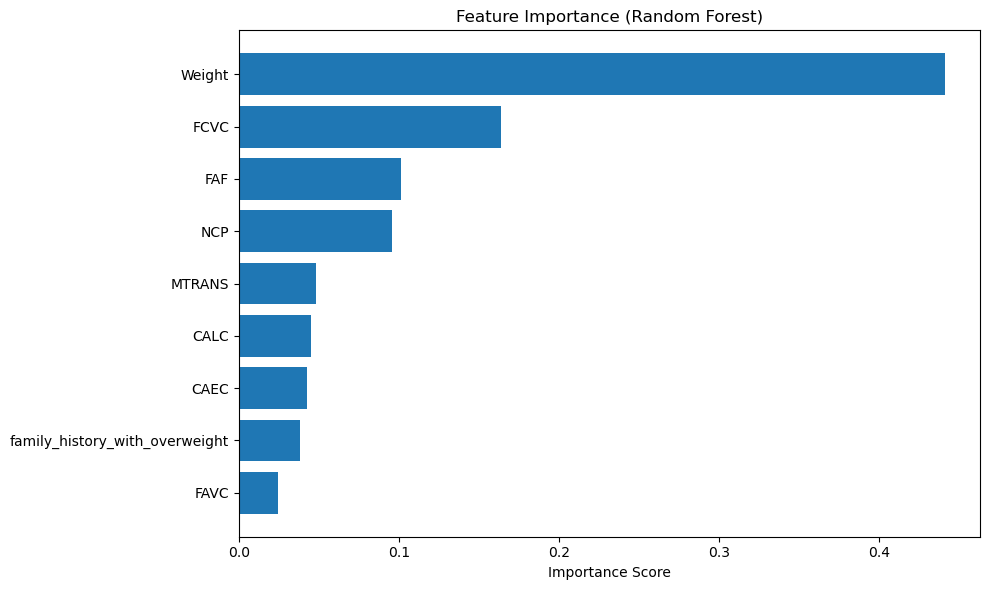

In [58]:
importances = model_random.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature':class_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


print(feature_importance_df.head())

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis() 
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In Random foreast model, the most importance of feature are : Weight,FCVC,FAF,NCP,MTRANS,CALC,CAEC,family_history_with_overweight,FAVC.

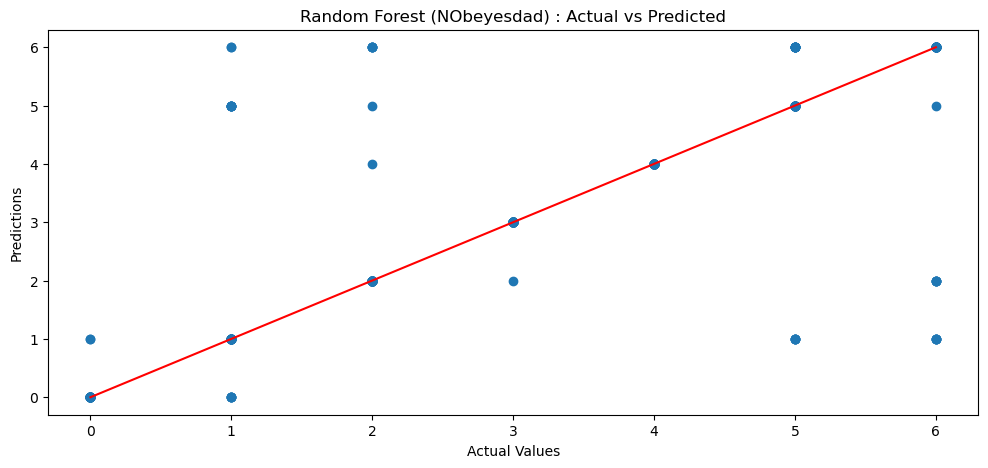

In [60]:
predictions_random = pd.DataFrame({
    'Actual Values': y_test,
    'Predictions': random_predict
})

plt.figure(figsize=(12, 5))
plt.scatter(predictions_random['Actual Values'], predictions_random['Predictions'])
plt.title('Random Forest (NObeyesdad) : Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red') 
plt.show()


### 7.2 KNN

                          Feature  Importance
8                          Weight    0.335545
4                            CALC    0.166114
2                            FCVC    0.161611
5                             NCP    0.137204
7                          MTRANS    0.128910
6                             FAF    0.121564
0  family_history_with_overweight    0.104976
1                            FAVC    0.084597
3                            CAEC    0.074645


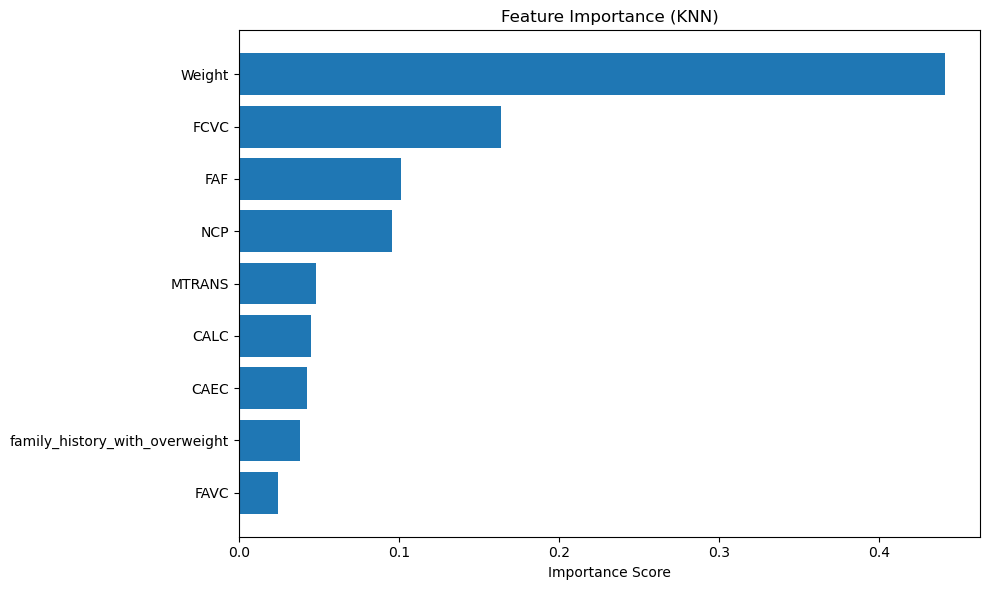

In [62]:
result = permutation_importance(model_knn, X_test, y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    'Feature': class_features,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis() 
plt.title('Feature Importance (KNN)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In KNN model, the most importance of feature are : Weight,FCVC,FAF,NCP,MTRANS,CALC,CAEC,family_history_with_overweight,FAVC.

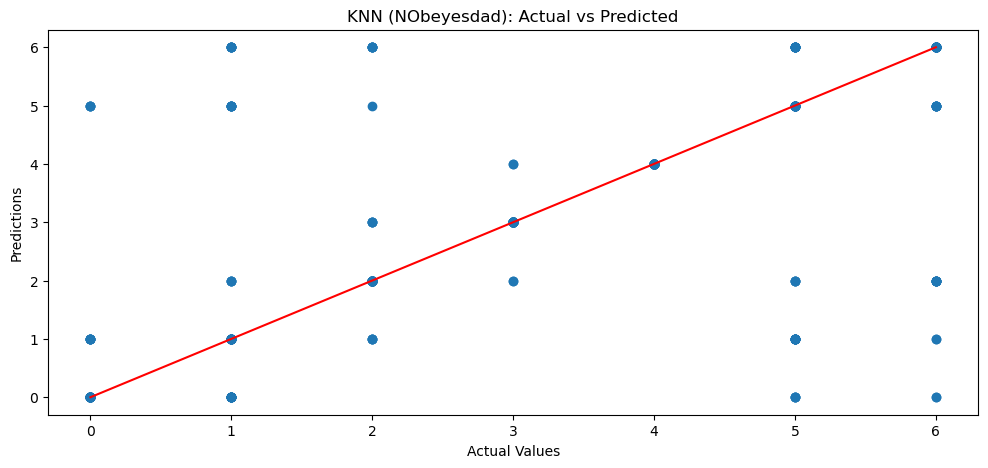

In [64]:
predictions_knn = pd.DataFrame({
    'Actual Values': y_test,
    'Predictions': y_pred_knn
})


plt.figure(figsize=(12, 5))
plt.scatter(predictions_knn['Actual Values'], predictions_knn['Predictions'])
plt.title('KNN (NObeyesdad): Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red') 
plt.show()

### 7.3 In Linear regression, the smaller the value of P-value, the more important the feature is.

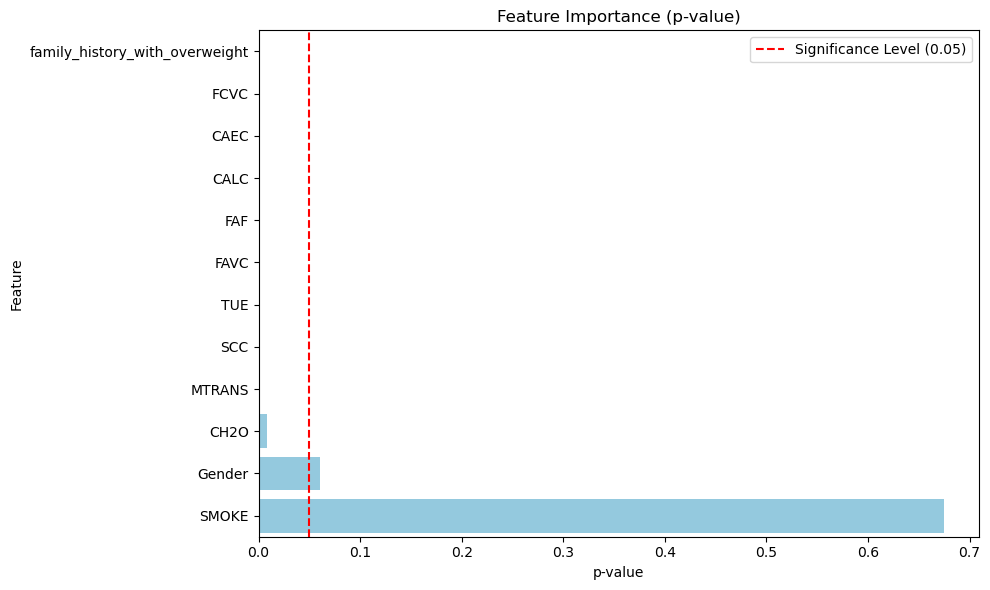

In [66]:
p_values = lr_model.pvalues.drop('const')

pval_df = pd.DataFrame({
    'Feature': p_values.index,
    'p-value': p_values.values
}).sort_values('p-value', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='p-value', y='Feature', data=pval_df, color='skyblue')
plt.axvline(x=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.xlabel('p-value')
plt.ylabel('Feature')
plt.title('Feature Importance (p-value)')
plt.legend()
plt.tight_layout()
plt.show()

In Linear regression model, the most importance of feature are : family_history_with_overweight,FCVC,CAEC,FAF,FAVA,CALC,TUE,SCC,MTRANS.

R² score: 0.43315572400424107
RMSE: 35.3468259779353


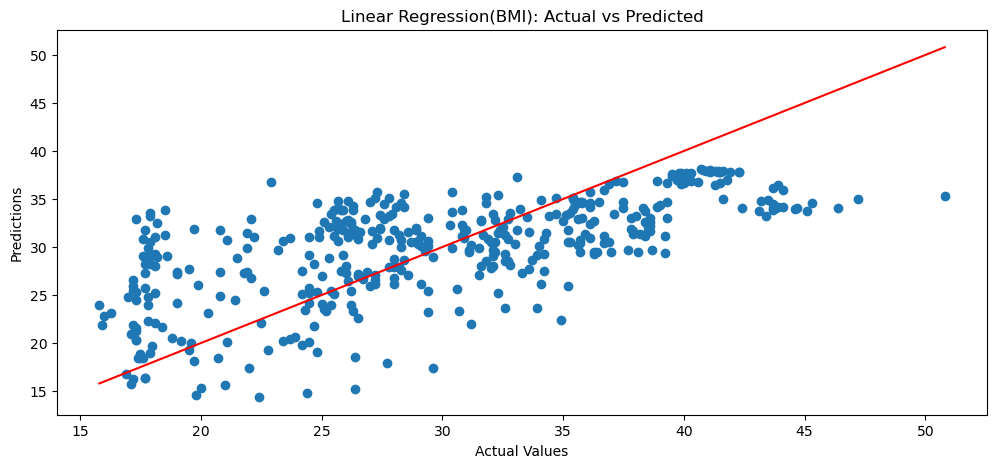

In [68]:
# R²
r2 = r2_score(y_test_reg, y_pred_reg)
print("R² score:", r2)

# RMSE
rmse = mean_squared_error(y_test_reg, y_pred_reg)
print("RMSE:", rmse)

plt.figure(figsize=(12, 5))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title("Linear Regression(BMI): Actual vs Predicted")
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], color='red') 
plt.show()

### 7.4 Compare the results from all candidate models

In [70]:
model_results = {
    'Model': ['Random Forest', 'KNN', 'Linear Regression'],
    'Accuracy': [RF_accuracy, KNN_accuracy, r2],
    'F1 Score': [RF_f1, KNN_precision, '-'],
    'Precision': [RF_precision, KNN_precision, '-'],
    'Recall': [RF_recall, KNN_recall, '-'],
    'Cross' : [cross_random,cross_knn,cross_reg]
}

df_results = pd.DataFrame(model_results)
df_results.set_index('Model', inplace=True)

df_results

,Accuracy,F1 Score,Precision,Recall,Cross
Model,,,,,
Random Forest,0.881517,0.881328,0.882594,0.881517,0.876683
KNN,0.741706,0.736235,0.736235,0.741706,0.748543
Linear Regression,0.433156,-,-,-,-5.746484


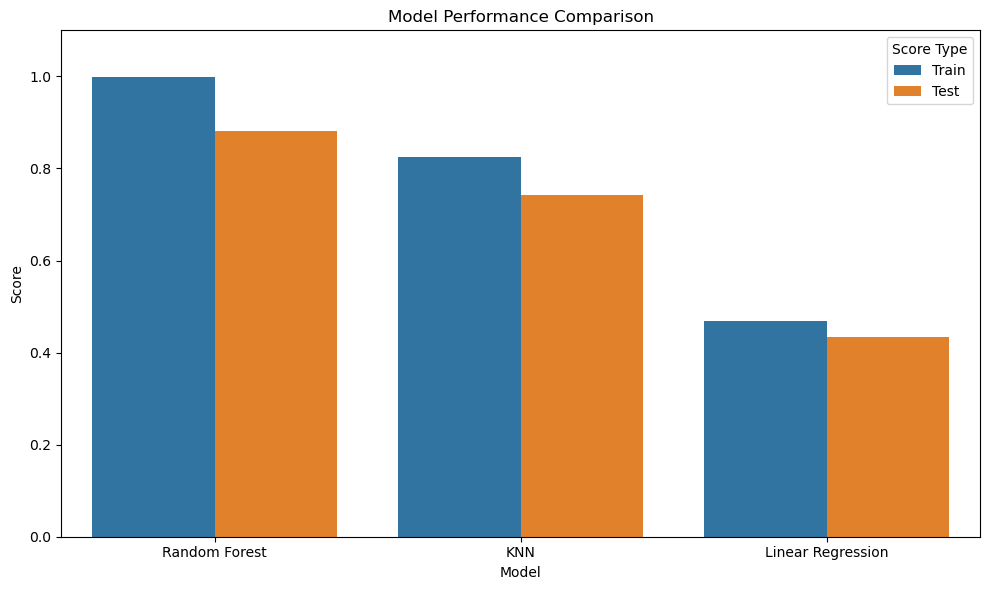

In [71]:
df_scores_grouped = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest', 'KNN', 'KNN', 'Linear Regression', 'Linear Regression'],
    'Score Type': ['Train', 'Test', 'Train', 'Test', 'Train', 'Test'],
    'Score': [
        result_dict_train['Random Forest'],
        result_dict_test['Random Forest'],
        result_dict_train['KNN'],
        result_dict_test['KNN'],
        result_dict_train['Linear Regression'],
        result_dict_test['Linear Regression']
    ]
})


plt.figure(figsize=(10, 6))
sns.barplot(data=df_scores_grouped, x='Model', y='Score', hue='Score Type')

plt.title("Model Performance Comparison")
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

Of the three models,Random forest has the best performs.

### 7.5 Conclusion

1. In classification model:<br>

   - **Random foreast**: If we change the feature select, it will get different score,like if I keep "Height" or "BMI" in features, the score will come to '0.98', it not make sense, so I remove those features.<br>
   
   - **KNN**: If we change "n_neighbors", the score will be different, thorugh times trying, the  n_neighbors = 5 could be the best k.
  
     
2. In regression model:<br>
   - **Linear Regression**: The importance of data can be analyzed, but the accuracy of the model is relatively poor.<br>
     


3. After comparing:<br>
   - **Random foreast** is the **best performer**,Linear Regression is the worst  performer.<br>
    
   - However, Linear Regression has strong feature selection ability, so it is the best choice to combine Linear Regression and Random foreast to analyze this problem.
    

   


### 8. Describe appropriate recommendations

Based on the important features we found, the government (or similar agency) could put out following health recommendations:


1. **Support families with obesity history**  
   From "family_history_with_overweight", we can see people with a family history of obesity are more likely to have high BMI. Give these families early help and health tips.

3. **Eat more vegetables**  
   From "FCVC", we can see eating vegetables often is linked to lower BMI. Teach people to choose vegetables in daily meals.

4. **Avoid snacks between meals**  
   From "CAEC", we can see people who snack a lot between meals may have higher BMI. Encourage regular meals without extra snacks.

5. **Be more active**  
   From "FAF" and "TUE", we can see doing physical activity and spending less time using screens helps control BMI. Promote fun ways to move more every day.

6. **Drink less alcohol**  
   From "CALC", we can see drinking alcohol often can lead to higher BMI. Promote drinking less or none at all.

7. **Choose better transport**  
    From "MTRANS", we can see walking or biking instead of driving is linked to lower BMI. Build safe ways to walk or cycle.


### 9. Reflect on what you have learned by completing this assignment

1. The first step is to divide the classification of the problem according to the **target output**, because there are two outcome formats for this topic. One is to use **NObeyesdad** to output a **multi-classification label**, and the other is to calculate **BMI** and predict a **specific value**. The first one is a classification problem, while the latter one is a linear regression problem.<br>

2. Check dataset, checking for missing value , dataset information, including: data size, data type.

3. When it comes to calculate a new number to a new clonmus, we should check data unit or if there has outlier.

4. Analysis all the data relationship,visualise the data.

5. In classification problem, I choose the important feature form visualise,in regression problem, I choose important from RFE.

6. Start to create the model, split the dataset into training set and testing set,find the important features that affect the model.

7. Get model analysis matrix, find solution, in classification problem, we can get **Accuracy**,**Precision**,**Recall**,**F1 Score** and **matrix** to evaluate the performance of the model, in regression problem, we can get **R² (R-squared)**,**RMSE** and **MSE** to evaluate the performance of the model.

### 10. References

Most of reference and code are from myuni workshop file,some of attribute are from official API file: 

1. Linear Regression model, visualization and performance evaluation methods: Workshop1.ipynb 
2. OLS Regression Results and Data standard scale methods: House-price-prediction-ridge-lasso-regression Solutions.ipynb
3. Label Encoding: Income_Evalutation-1.ipynb
4. Tain_test_split:Income_Evalutation-WO Sols.ipynb
5. Feature performance: https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html
6. Confusion_matrix: Workshop Week 4.ipynb
7. mean_squared_error : house-price-prediction-ridge-lasso-regression.ipynb